In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('Social_Network_Ads.csv')

In [3]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df['Gender'].replace({'Male':0, 'Female':1}, inplace= True)

In [5]:
df['Gender']

0      0
1      0
2      1
3      1
4      0
      ..
395    1
396    0
397    1
398    0
399    1
Name: Gender, Length: 400, dtype: int64

In [6]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [7]:
X= df[['User ID','Gender','Age', 'EstimatedSalary']]
Y=df['Purchased']

In [8]:
X_train, X_test, Y_train,Y_test= train_test_split(X, Y,test_size=0.25,random_state=29)

In [9]:
model= LogisticRegression()
model.fit(X_train, Y_train)

LogisticRegression()

In [10]:
Y_pred= model.predict(X_test)

In [11]:
model.score(X_train, Y_train)

0.7833333333333333

In [12]:
cm= confusion_matrix(Y_test, Y_pred)

In [13]:
print(confusion_matrix.__doc__)

Compute confusion matrix to evaluate the accuracy of a classification.

    By definition a confusion matrix :math:`C` is such that :math:`C_{i, j}`
    is equal to the number of observations known to be in group :math:`i` and
    predicted to be in group :math:`j`.

    Thus in binary classification, the count of true negatives is
    :math:`C_{0,0}`, false negatives is :math:`C_{1,0}`, true positives is
    :math:`C_{1,1}` and false positives is :math:`C_{0,1}`.

    Read more in the :ref:`User Guide <confusion_matrix>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,)
        Estimated targets as returned by a classifier.

    labels : array-like of shape (n_classes), default=None
        List of labels to index the matrix. This may be used to reorder
        or select a subset of labels.
        If ``None`` is given, those that appear at least once
        in ``y

In [14]:
tn,fp,fn,tp= confusion_matrix(Y_test,Y_pred).ravel()

In [15]:
print(tn, fp, fn, tp)

64 5 16 15


In [16]:
a= accuracy_score(Y_test, Y_pred)

In [17]:
a

0.79

In [18]:
e= 1-a
e

0.20999999999999996

In [19]:
precision_score(Y_test, Y_pred)

0.75

In [20]:
recall_score(Y_test, Y_pred)

0.4838709677419355

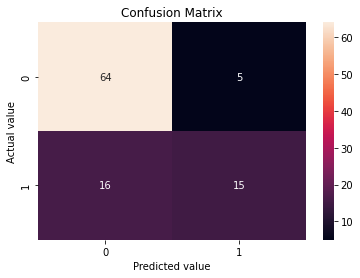

In [21]:
sns.heatmap(cm, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actual value')
plt.xlabel('Predicted value')
plt.show()